# Explorar datos a nivel de establecimiento educativo

Objetivos

- Analizar relación entre las variables que caracterizan a los establecimientos
- Identificar casos outliers para revisar pre-procesamiento de los datos

Datos utilizados:

- Puntajes SIMCE matemáticas 2do medio (2024)
- Características de los docentes (2025)
- Indicadores de desarrollo personal y social (2024)

## Cargar librerías y datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = '/Users/vcanalesg/Documents/diplomado_dcc/0_taller_proyecto/datos'
rbd = pd.read_parquet(path + '/rbd_consolidado.parquet')

## Exploración básica de los datos

- Dimensiones del dataset
- Listado de variables
- Conteo de casos perdidos (pendiente)

In [3]:
print('El dataset tiene ' + str(rbd.shape[0]) + ' establecimientos de educación y ' + str(rbd.shape[1]) + ' variables.')

# list(rbd.columns)

El dataset tiene 3000 establecimientos de educación y 184 variables.


## Selección de establecimiento a analizar

No todos los establecimientos tienen puntajes Simce de matemáticas válidos. Esto ocurre por diversos motivos:
- No tienen valor en el promedio del establecimiento (esto podría haberse dado porque el número de estudiantes es muy pequeño).
- El promedio se presenta, pero está marcado como no representativo del desempeño de los estudiantes por factores ajenos a la Agencia.


In [27]:
# marca_mate2m_rbd tiene valor NA cuando el puntaje es válido
# prom_mate2m_rbd corresponde al promedio simce del establecimiento.
rbd_filtrado = rbd[rbd['marca_mate2m_rbd'].isna() | (rbd['prom_mate2m_rbd'].isna() == False)]

# rbd_filtrado.value_counts('cod_grupo')

# solo establecimientos con GSE bajo y medio-bajo
# rbd_gse_medio_bajo = rbd_filtrado[rbd_filtrado['cod_grupo'].isin([1,2])]

# estableciientos con GSE medio-alto y alto
rbd_gse_medio_alto = rbd_filtrado[rbd_filtrado['cod_grupo'].isin([4,5])]

## Análisis por variable

Revisar distribución univariada de las características de los establecimientos por:

- Grupo socioeconómico (cod_grupo)
- Dependencia administrativa establecimiento (cod_depe2)
- Región establecimiento educacional (cod_reg_rbd)
- Puntaje simce matemáticas (prom_mate2m_rbd)
- Porcentaje de mujeres matriculadas (p_mujer_2do_medio)
- Porcentaje de rezagados (p_rezago_2do_medio)
- Índice de autoestima académica y motivación escolar (ind_am)
- Clima de convivencia escolar (ind_cc)
- Participación y formación ciudadana (ind_pf)
- Hábitos de vida saludable (hv)
- Índices sistema SNED (superar, mejorar, iniciar, igualdr)
- Número de docentes de matemáticas 2do medio por matriculados en el curso (n_docentes_estudiantes) 

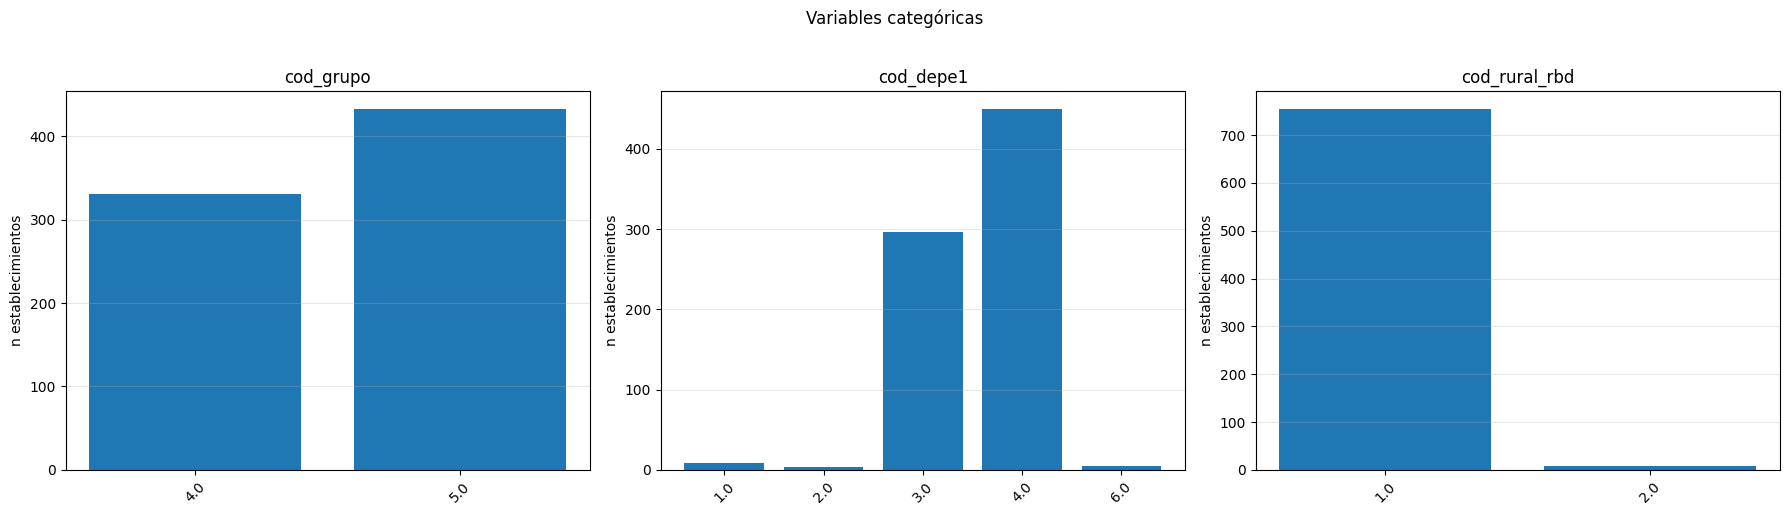

In [28]:
cat_vars = ['cod_grupo', 'cod_depe1', 'cod_rural_rbd']

fig, axes = plt.subplots(1, len(cat_vars), figsize=(18, 5))

for ax, var in zip(axes, cat_vars):
    counts = rbd_gse_medio_alto[var].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(var)
    ax.set_ylabel('n establecimientos')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Variables categóricas', y=1.02)
plt.tight_layout()
plt.show()

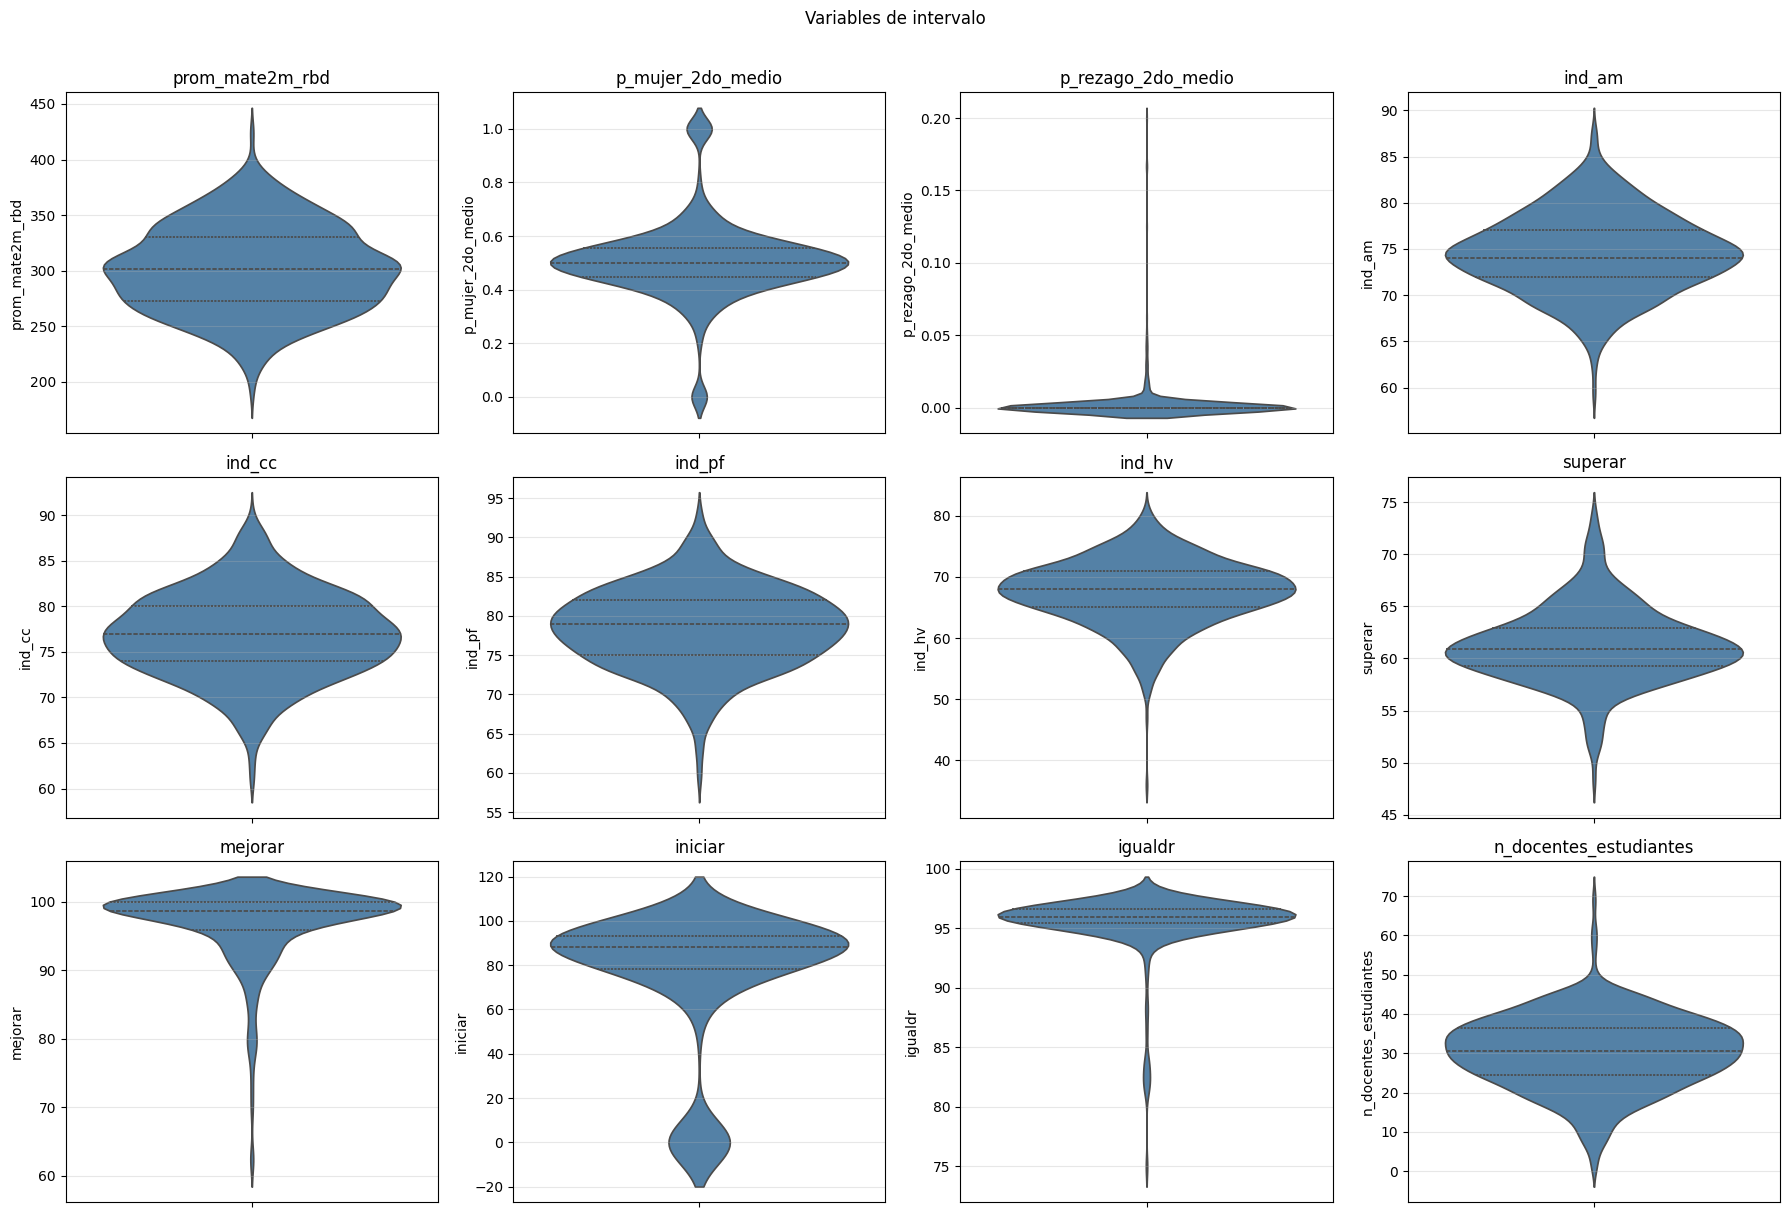

In [29]:
cont_vars = [
    'prom_mate2m_rbd', 'p_mujer_2do_medio', 'p_rezago_2do_medio',
    'ind_am', 'ind_cc', 'ind_pf', 'ind_hv',
    'superar', 'mejorar', 'iniciar', 'igualdr', 'n_docentes_estudiantes'
]

n_cols = 4
n_rows = int(np.ceil(len(cont_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.reshape(n_rows, n_cols)

for ax, var in zip(axes.flat, cont_vars):
    subset = rbd_gse_medio_alto[[var]].dropna()
    sns.violinplot(data=subset, y=var, ax=ax, color='steelblue', inner='quartile')
    ax.set_title(var)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3, axis='y')

for ax in axes.flat[len(cont_vars):]:
    ax.set_visible(False)

plt.suptitle('Variables de intervalo', y=1.01)
plt.tight_layout()
plt.show()



## Análisis de asociación de variables

Revisar relación entre indicadores de desarrollo personal y social y los puntajes Simce para 2do medio.

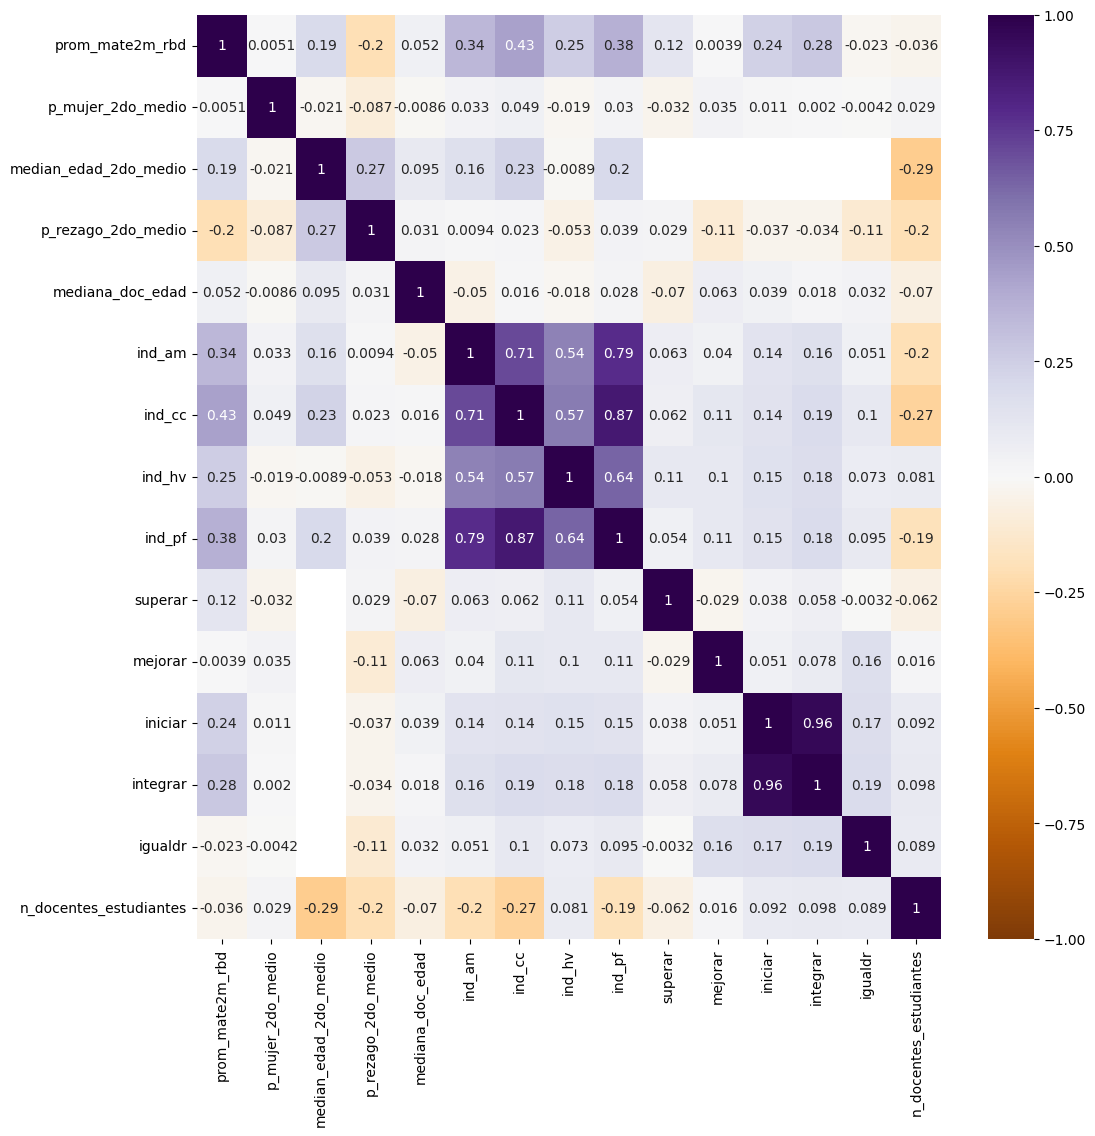

In [30]:
# Variables a considerar:
# prom_mate2m_rbd: promedio simce del establecimiento
# p_mujer_2do_medio: porcentaje de mujeres matriculadas en 2do medio
# median_edad_2do_medio: mediana de edad para matriculados 2do medio
# p_rezago_2do_medio: porcentaje de rezagados
# ind_am: autoestima académica y motivación escolar
# ind_cc: clima de convivencia escolar
# ind_hv: participación y formación ciudadana
# ind_pf: hábitos de vida saludable
# 'superar', 'mejorar','iniciar', 'integrar', 'igualdr' (SNED)

variables = ['prom_mate2m_rbd', 'p_mujer_2do_medio', 'median_edad_2do_medio', 'p_rezago_2do_medio','mediana_doc_edad',
             #'dim_aa','dim_me', 'dim_ao','dim_ar', 'dim_as','dim_ac', 'dim_ha', 'dim_va', 'dim_pa', 'dim_sp', 'dim_vd',
             'ind_am', 'ind_cc', 'ind_hv', 'ind_pf',
             'superar', 'mejorar','iniciar', 'integrar', 'igualdr',
             'n_docentes_estudiantes']

plt.figure(figsize = (12, 12))

sns.heatmap(rbd_gse_medio_alto[variables].corr(),
            annot=True,
            vmin=-1, vmax=1,
            cmap='PuOr');




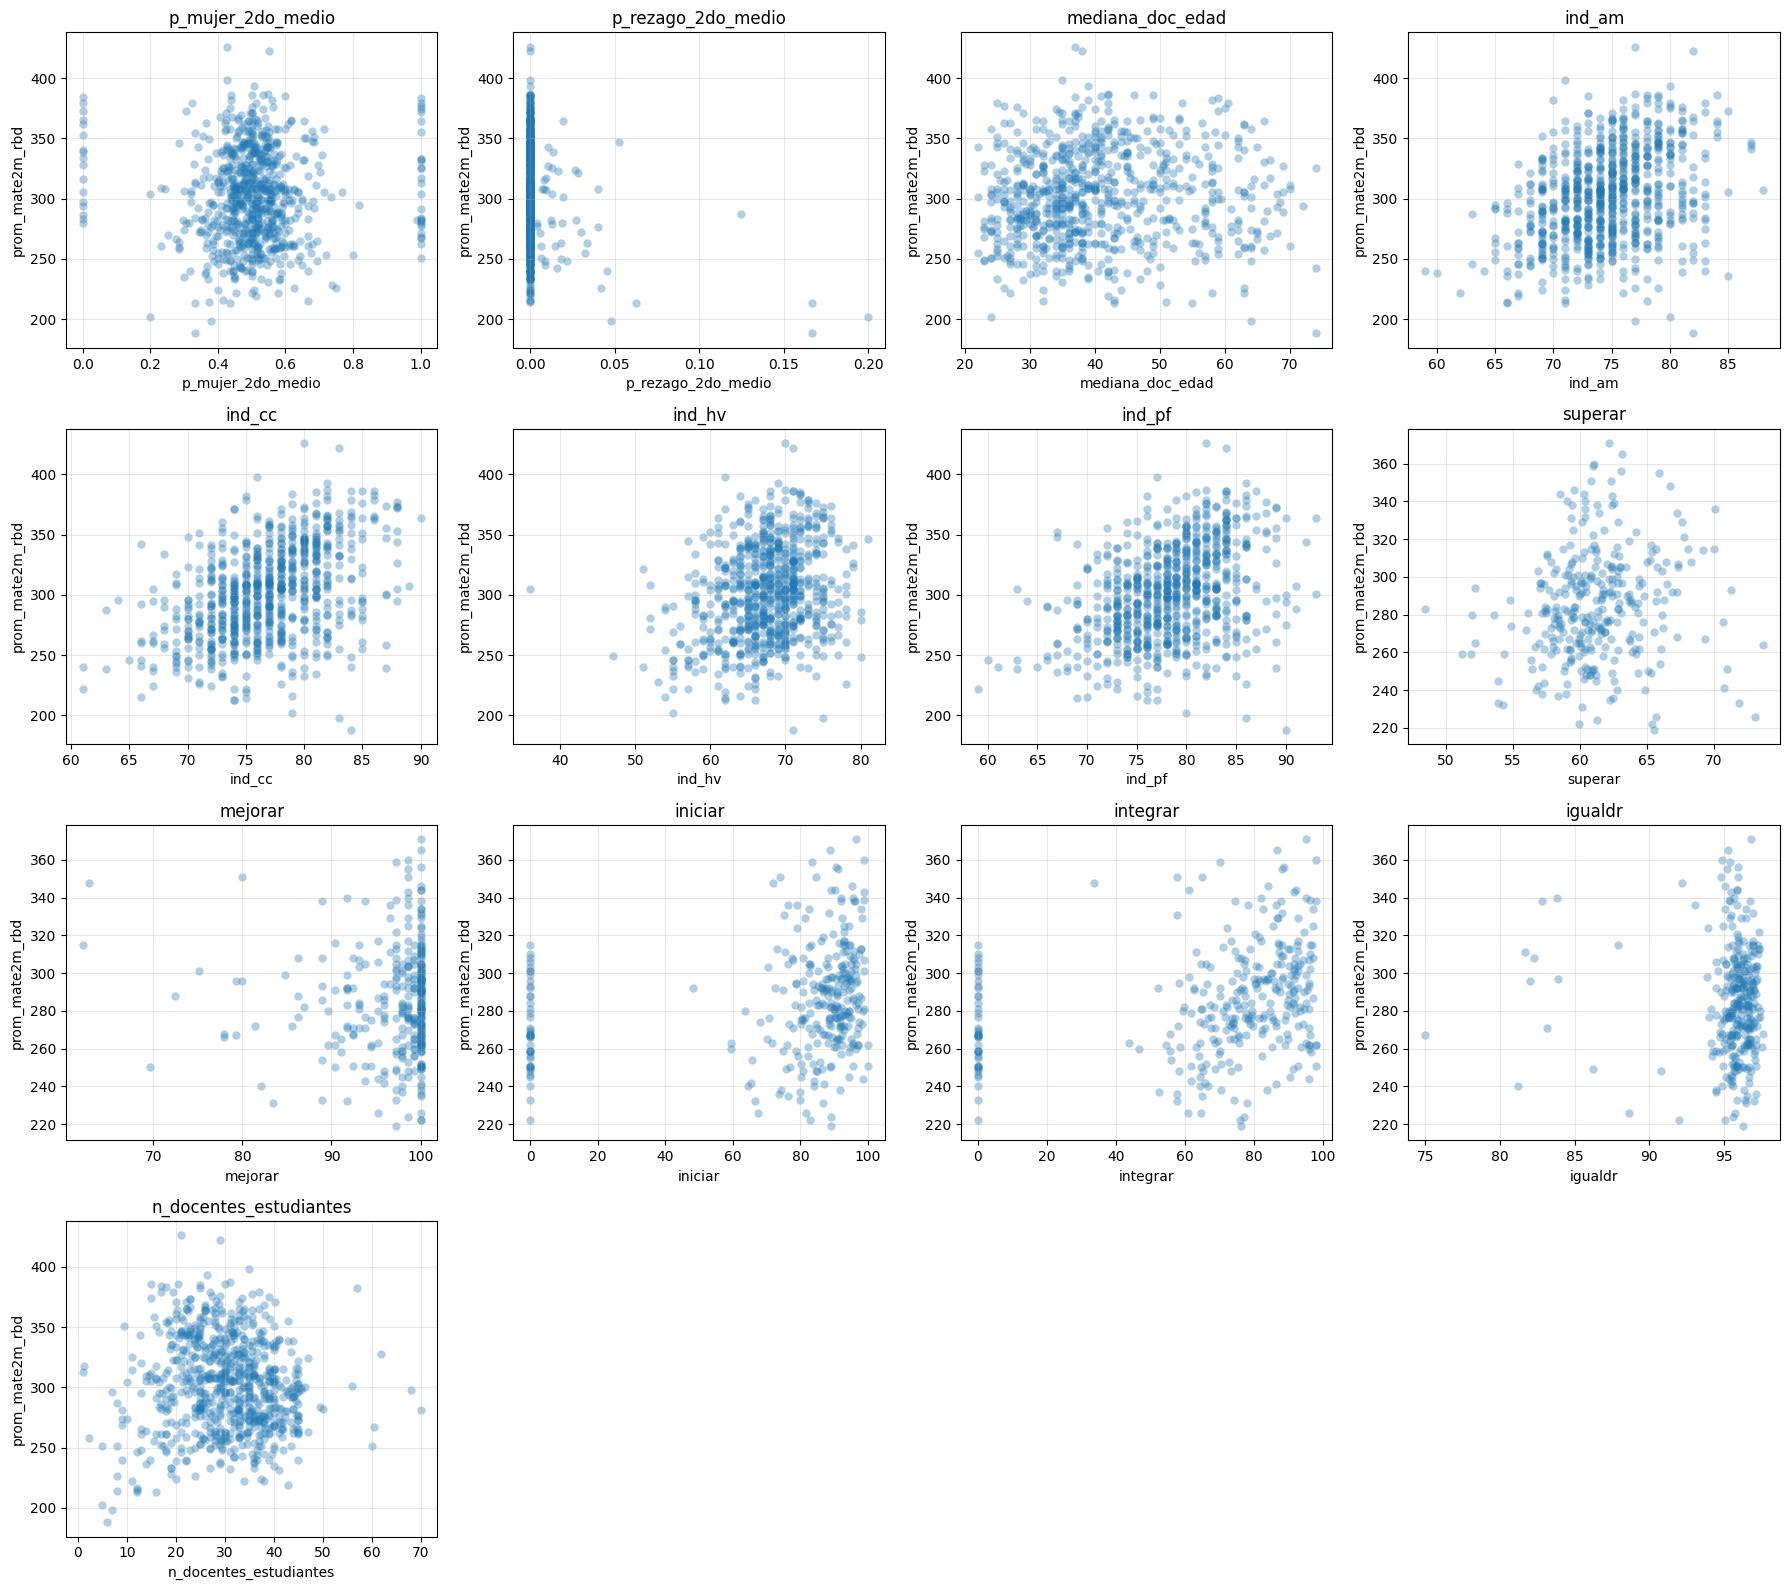

In [31]:
variables = ['p_mujer_2do_medio', 'p_rezago_2do_medio','mediana_doc_edad',
             #'dim_aa','dim_me', 'dim_ao','dim_ar', 'dim_as','dim_ac', 'dim_ha', 'dim_va', 'dim_pa', 'dim_sp', 'dim_vd',
             'ind_am', 'ind_cc', 'ind_hv', 'ind_pf',
             'superar', 'mejorar','iniciar', 'integrar', 'igualdr',
            'n_docentes_estudiantes']

n_vars = len(variables)
n_cols = 4
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for ax, var in zip(axes.flat, variables):
    subset = rbd_gse_medio_alto[[var, 'prom_mate2m_rbd']].dropna()
    sns.scatterplot(
        data=subset,
        x=var,
        y='prom_mate2m_rbd',
        alpha=0.35,
        linewidth=0,
        ax=ax
    )
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel('prom_mate2m_rbd')
    ax.grid(True, alpha=0.3)

for ax in axes.flat[len(variables):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Explorar estructura de agrupación

- Cluster jerárquico aglomerativo: no asume número de cluster ni distribución subyacente.

- RobustScaler utiliza mediana y IQR para escalar las variables

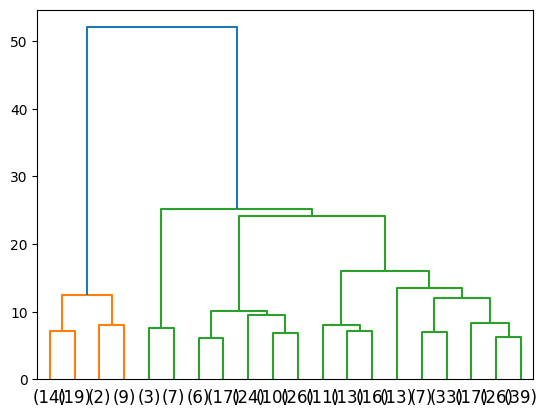

In [37]:
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import RobustScaler  # usa mediana e IQR, no media/std
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

features = ['prom_mate2m_rbd', 'p_rezago_2do_medio', 'ind_am', 'ind_cc',
            'ind_hv', 'ind_pf', 'superar', 'mejorar', 'iniciar']

X = rbd_gse_medio_alto[features].dropna()
X_scaled = RobustScaler().fit_transform(X)


Z = linkage(X_scaled, method='ward')  # ward es robusto con RobustScaler
dendrogram(Z, truncate_mode='lastp', p=20)
plt.show()

labels = fcluster(Z, t=4, criterion='maxclust')  # cortar en 4 grupos
